<a href="https://colab.research.google.com/github/bloodrepaer/nifty-vix-kalman/blob/main/vix_kalman_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VIX Kalman Regime Engine — NIFTY50
**Data**: NIFTY50 1-min OHLC, 2017–2025 (805k bars)  
**Approach**: Kalman filter on India VIX → 7 volatility regimes → vol-targeted position sizing  
**Execution**: Daily, 8bps round-trip slippage, flat overnight

In [1]:
pip install pykalman

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 12.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from pykalman import KalmanFilter
from scipy.stats import percentileofscore
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

NIFTY_CSV          = 'Nifty50_data.csv'
INITIAL_CAPITAL    = 100_000
RISK_FREE_RATE     = 0.065
VOL_TARGET         = 0.20
MAX_LEVERAGE       = 3.0
SLIPPAGE_BPS       = 8
DD_CIRCUIT_BREAKER = 0.10
VIX_ZSCORE_WINDOW  = 126
VIX_PCT_WINDOW     = 252
VIX_SPIKE_THRESH   = 0.20

REGIME_SCALARS = {
    'Extreme Panic': 0.65,
    'Panic':         0.80,
    'Fear (live)':   0.75,
    'Fear (buy)':    1.20,
    'Recovery':      2.00,
    'Calm':          1.80,
    'Neutral':       1.20,
}

C = dict(green='#00ff88', blue='#00bfff', red='#ff4466',
         gold='#ffdd00', grid='#2a2a2a', text='#cccccc', bg='#0d0d0d', panel='#141414')

print('Config loaded.')

Config loaded.


In [3]:
# ── Load 1-min data, resample to daily ────────────────────────────────────────
df = pd.read_csv(NIFTY_CSV)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_convert('Asia/Kolkata')
df = df.set_index('datetime').sort_index()
df = df.drop(columns=[c for c in ['volume','oi'] if c in df.columns])
df = df.between_time('09:15','15:30')

daily = df.resample('D').agg({'open':'first','high':'max','low':'min','close':'last'}).dropna()
daily.index = daily.index.tz_localize(None)

print(f'Daily bars : {len(daily)} trading days')
print(f'Range      : {daily.index[0].date()} to {daily.index[-1].date()}')

# ── Download India VIX ────────────────────────────────────────────────────────
start_str = str(daily.index[0].date())
end_str   = str((daily.index[-1] + pd.Timedelta(days=1)).date())
vix_dl    = yf.download('^INDIAVIX', start=start_str, end=end_str, progress=False, auto_adjust=True)
vix_raw   = vix_dl['Close']['^INDIAVIX'] if isinstance(vix_dl.columns, pd.MultiIndex) else vix_dl['Close']
vix_raw.index = pd.to_datetime(vix_raw.index).tz_localize(None)
vix_raw.name  = 'VIX'
print(f'VIX days   : {len(vix_raw)}')

Daily bars : 2148 trading days
Range      : 2017-01-02 to 2025-09-11
VIX days   : 2131


In [4]:
# ── Kalman filter on VIX [level, velocity] ────────────────────────────────────
kf = KalmanFilter(
    transition_matrices=np.array([[1,1],[0,1]]),
    observation_matrices=np.array([[1,0]]),
    initial_state_mean=[float(vix_raw.iloc[0]), 0.0],
    initial_state_covariance=np.eye(2),
    transition_covariance=np.eye(2)*1e-4,
    observation_covariance=np.array([[0.8]])
)
states, _ = kf.filter(vix_raw.values)

vix = pd.DataFrame({
    'VIX':     vix_raw.values,
    'KF_Level':states[:,0],
    'KF_Vel':  states[:,1]
}, index=vix_raw.index)

# Z-score (126-day rolling)
rm = vix['KF_Level'].rolling(VIX_ZSCORE_WINDOW, min_periods=21).mean()
rs = vix['KF_Level'].rolling(VIX_ZSCORE_WINDOW, min_periods=21).std().replace(0, np.nan)
vix['VIX_Z'] = (vix['KF_Level'] - rm) / rs

# Percentile (252-day rolling)
def rpct(x):
    return percentileofscore(x[:-1], x.iloc[-1]) / 100.0
vix['VIX_Pct'] = vix['VIX'].rolling(VIX_PCT_WINDOW, min_periods=63).apply(rpct, raw=False)

# Velocity z-score
vel_std = vix['KF_Vel'].rolling(42, min_periods=14).std().replace(0, np.nan)
vix['VelZ'] = vix['KF_Vel'] / vel_std

# Panic spike detector
vix['Spike'] = (vix['VIX'].pct_change() > VIX_SPIKE_THRESH).astype(int).rolling(3, min_periods=1).max()

print(f'VIX Z-score: {vix["VIX_Z"].min():.2f} to {vix["VIX_Z"].max():.2f}')
print(f'Panic spikes: {vix["Spike"].sum()}')

VIX Z-score: -2.90 to 6.18
Panic spikes: 51.0


In [5]:
# ── Regime state machine (priority-ordered) ───────────────────────────────────
vz    = vix['VIX_Z'].fillna(0)
velz  = vix['VelZ'].fillna(0)
pct   = vix['VIX_Pct'].fillna(0.5)
spike = vix['Spike']

is_ep   = (vz > 3.0)
is_p    = (~is_ep) & ((vz > 2.0) | (spike > 0))
is_fl   = (~is_ep) & (~is_p) & (vz > 1.2) & (velz > 0.5)
is_fb   = (~is_ep) & (~is_p) & (vz > 1.2) & (velz <= 0.5)
is_rec  = (~is_ep) & (~is_p) & (~is_fl) & (~is_fb) & (velz < -1.0) & (pct > 0.45)
is_calm = (~is_ep) & (~is_p) & (~is_fl) & (~is_fb) & (~is_rec) & (vz < -0.3)

regime = np.where(is_ep,   'Extreme Panic',
          np.where(is_p,   'Panic',
          np.where(is_fl,  'Fear (live)',
          np.where(is_fb,  'Fear (buy)',
          np.where(is_rec, 'Recovery',
          np.where(is_calm,'Calm', 'Neutral'))))))

vix['Regime'] = regime
vix['Scalar'] = pd.Series(regime, index=vix.index).map(REGIME_SCALARS)

total = len(regime)
print(f'Regime distribution ({total} days):')
for r in ['Extreme Panic','Panic','Fear (live)','Fear (buy)','Recovery','Calm','Neutral']:
    n = (regime == r).sum()
    print(f'  {r:<16}: {n:>4} days ({n/total*100:.1f}%)  scalar {REGIME_SCALARS[r]}x')

Regime distribution (2131 days):
  Extreme Panic   :   98 days (4.6%)  scalar 0.65x
  Panic           :  179 days (8.4%)  scalar 0.8x
  Fear (live)     :   97 days (4.6%)  scalar 0.75x
  Fear (buy)      :   60 days (2.8%)  scalar 1.2x
  Recovery        :  172 days (8.1%)  scalar 2.0x
  Calm            :  928 days (43.5%)  scalar 1.8x
  Neutral         :  597 days (28.0%)  scalar 1.2x


In [6]:
# ── Backtest ──────────────────────────────────────────────────────────────────
ma5      = daily['close'].rolling(5).mean()
trend_ok = (daily['close'] > ma5).rename('TrendOK')

data = pd.concat([
    daily['close'].rename('NIFTY'),
    vix[['VIX_Z','Regime','Scalar']],
    trend_ok
], axis=1).ffill().dropna()
ret = data['NIFTY'].pct_change().fillna(0)

# Trend filter: cap scalar at 1.0x when market is below 5-day MA
data['Scalar_use'] = data['Regime'].map(REGIME_SCALARS)
data['Scalar_use'] = np.where(data['TrendOK'], data['Scalar_use'], data['Scalar_use'].clip(0, 1.0))

# Vol-targeted position size
ewma_vol   = ret.ewm(span=21).std() * np.sqrt(252)
vol_scalar = (VOL_TARGET / ewma_vol.replace(0, np.nan)).clip(0.3, MAX_LEVERAGE)
raw_pos    = (data['Scalar_use'] * vol_scalar).clip(0, MAX_LEVERAGE).ewm(span=2).mean()

# Circuit breaker with gradual VIX-gated recovery
pos_arr   = raw_pos.values.copy()
ret_arr   = ret.values
vz_arr    = data['VIX_Z'].fillna(0).values
equity    = np.zeros(len(pos_arr))
equity[0] = INITIAL_CAPITAL
final_pos = np.zeros(len(pos_arr))
brake     = 1.0

for i in range(1, len(pos_arr)):
    final_pos[i] = pos_arr[i] * brake
    slip         = abs(final_pos[i] - final_pos[i-1]) * (SLIPPAGE_BPS / 10_000)
    equity[i]    = equity[i-1] * (1 + final_pos[i] * ret_arr[i] - slip)
    if i >= 20:
        peak_20 = np.max(equity[max(0,i-20):i+1])
        dd_20   = (equity[i] - peak_20) / peak_20
        if dd_20 < -DD_CIRCUIT_BREAKER:
            brake = 0.25
        elif brake < 1.0 and vz_arr[i] < 1.0:
            brake = 0.50 if brake == 0.25 else 1.00

strat_eq  = pd.Series(equity, index=data.index)
strat_ret = pd.Series(final_pos, index=data.index) * ret - \
            pd.Series(final_pos, index=data.index).diff().abs().fillna(0) * (SLIPPAGE_BPS/10_000)
bench_eq  = INITIAL_CAPITAL * (1 + ret).cumprod()

print(f'Strategy equity : Rs{strat_eq.iloc[-1]:,.0f}')
print(f'Benchmark equity: Rs{bench_eq.iloc[-1]:,.0f}')

Strategy equity : Rs3,105,625
Benchmark equity: Rs292,268


In [7]:
# ── Performance metrics ───────────────────────────────────────────────────────
def compute_metrics(ret, name):
    r   = ret[ret != 0].dropna()
    ann = r.mean() * 252
    vol = r.std()  * np.sqrt(252)
    sh  = (ann - RISK_FREE_RATE) / vol if vol else 0
    eq  = INITIAL_CAPITAL * (1 + r).cumprod()
    pk  = eq.cummax()
    dd  = (eq - pk) / pk
    mdd = dd.min()
    cal = ann / abs(mdd) if mdd else 0
    dn  = r[r < 0]
    srt = (ann - RISK_FREE_RATE) / (dn.std() * np.sqrt(252)) if len(dn) else 0
    wr  = (r > 0).mean()
    pf  = r[r>0].sum() / abs(r[r<0].sum()) if len(r[r<0]) else np.inf
    in_dd = (dd < -0.01).astype(int)
    grp   = (in_dd != in_dd.shift()).cumsum()
    mdd_d = int(in_dd.groupby(grp).sum().max()) if len(in_dd) else 0

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    for label, val, fmt in [
        ('Ann. Return',     ann*100,  '{:>10.1f}%'),
        ('Ann. Volatility', vol*100,  '{:>10.1f}%'),
        ('Sharpe',          sh,       '{:>10.2f}x'),
        ('Sortino',         srt,      '{:>10.2f}x'),
        ('Max Drawdown',    mdd*100,  '{:>10.1f}%'),
        ('Calmar',          cal,      '{:>10.2f}x'),
        ('Win Rate',        wr*100,   '{:>10.1f}%'),
        ('Profit Factor',   pf,       '{:>10.2f}x'),
        ('Max DD Duration', mdd_d,    '{:>10d}d'),
    ]:
        print(f'  {label:<22} {fmt.format(val)}')
    print(f'{"="*50}')
    return {'ann':ann,'vol':vol,'sharpe':sh,'mdd':mdd,'calmar':cal,
            'sortino':srt,'wr':wr,'pf':pf,'mdd_days':mdd_d}, dd


strat_m, strat_dd = compute_metrics(strat_ret, 'VIX Kalman Strategy')
bench_m, bench_dd = compute_metrics(ret,        'NIFTY50 Buy & Hold')


  VIX Kalman Strategy
  Ann. Return                  43.0%
  Ann. Volatility              21.9%
  Sharpe                       1.67x
  Sortino                      2.80x
  Max Drawdown                -28.1%
  Calmar                       1.53x
  Win Rate                     53.7%
  Profit Factor                1.38x
  Max DD Duration               237d

  NIFTY50 Buy & Hold
  Ann. Return                  14.1%
  Ann. Volatility              16.5%
  Sharpe                       0.46x
  Sortino                      0.55x
  Max Drawdown                -38.2%
  Calmar                       0.37x
  Win Rate                     54.3%
  Profit Factor                1.17x
  Max DD Duration               236d


In [8]:
# ── Annual returns ────────────────────────────────────────────────────────────
ann_s = strat_ret.resample('YE').apply(lambda x: (1+x).prod()-1) * 100
ann_b = ret.resample('YE').apply(lambda x: (1+x).prod()-1) * 100
ann   = pd.DataFrame({'Strategy %': ann_s.round(1), 'Benchmark %': ann_b.round(1)})
ann.index     = ann.index.year
ann['Alpha %'] = (ann['Strategy %'] - ann['Benchmark %']).round(1)
ann['Beat']    = ann['Alpha %'].apply(lambda x: 'YES' if x > 0 else 'NO')
print(ann.to_string())

      Strategy %  Benchmark %  Alpha % Beat
2017        69.9         23.0     46.9  YES
2018        41.6          3.2     38.4  YES
2019        36.2         12.1     24.1  YES
2020        92.2         14.7     77.5  YES
2021        77.3         24.3     53.0  YES
2022        25.0          4.3     20.7  YES
2023        64.4         19.9     44.5  YES
2024        24.5          8.9     15.6  YES
2025         8.7          5.7      3.0  YES


Dashboard saved.


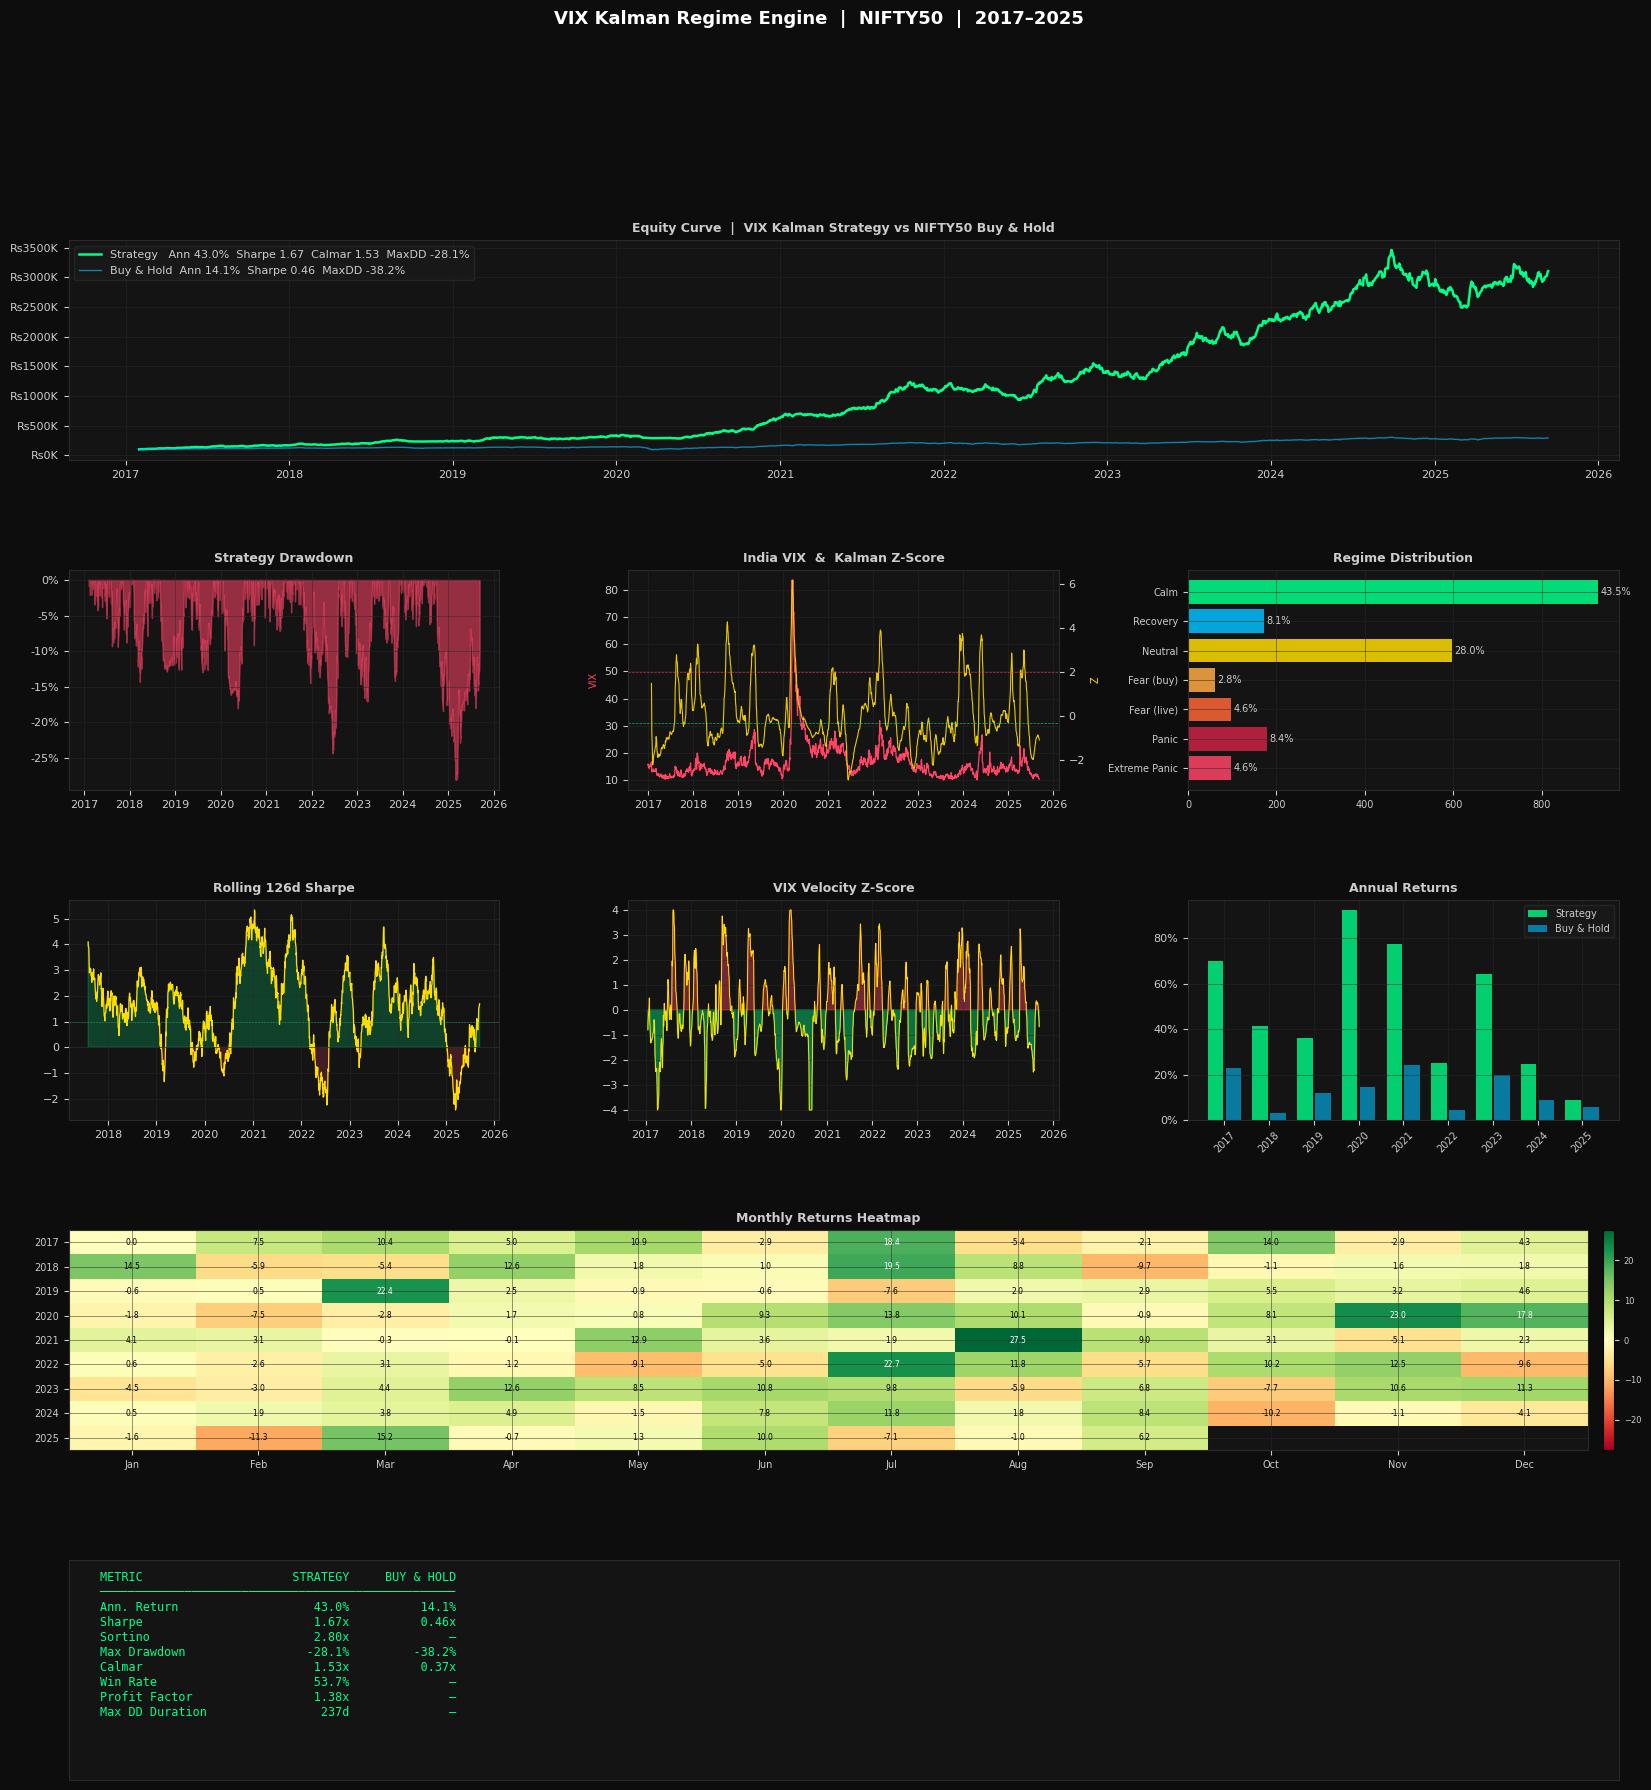

In [9]:
# ── Dashboard ─────────────────────────────────────────────────────────────────
def style(ax, title):
    ax.set_facecolor(C['panel'])
    ax.tick_params(colors=C['text'], labelsize=8)
    ax.set_title(title, color=C['text'], fontsize=9, fontweight='bold', pad=6)
    for sp in ax.spines.values(): sp.set_color(C['grid'])
    ax.grid(True, color=C['grid'], linewidth=0.5, alpha=0.7)

fig = plt.figure(figsize=(20, 20))
fig.patch.set_facecolor(C['bg'])
gs  = gridspec.GridSpec(5, 3, figure=fig, hspace=0.50, wspace=0.30)

# Equity curve
ax1 = fig.add_subplot(gs[0, :])
style(ax1, 'Equity Curve  |  VIX Kalman Strategy vs NIFTY50 Buy & Hold')
ax1.plot(strat_eq.index, strat_eq, color=C['green'], lw=1.8,
         label=f"Strategy   Ann {strat_m['ann']*100:.1f}%  Sharpe {strat_m['sharpe']:.2f}  Calmar {strat_m['calmar']:.2f}  MaxDD {strat_m['mdd']*100:.1f}%")
ax1.plot(bench_eq.index, bench_eq, color=C['blue'], lw=1.0, alpha=0.65,
         label=f"Buy & Hold  Ann {bench_m['ann']*100:.1f}%  Sharpe {bench_m['sharpe']:.2f}  MaxDD {bench_m['mdd']*100:.1f}%")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rs{x/1000:.0f}K'))
ax1.legend(fontsize=8, facecolor='#1a1a1a', edgecolor=C['grid'], labelcolor=C['text'], loc='upper left')

# Drawdown
ax2 = fig.add_subplot(gs[1, 0])
style(ax2, 'Strategy Drawdown')
ax2.fill_between(strat_dd.index, strat_dd*100, 0, color=C['red'], alpha=0.55)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

# VIX + Z-score
ax3 = fig.add_subplot(gs[1, 1])
style(ax3, 'India VIX  &  Kalman Z-Score')
ax3b = ax3.twinx()
ax3.plot(vix.index,  vix['VIX'],   color=C['red'],  lw=0.9)
ax3b.plot(vix.index, vix['VIX_Z'], color=C['gold'], lw=0.8, alpha=0.9)
ax3b.axhline(2.0,  color=C['red'],   lw=0.5, ls='--', alpha=0.7)
ax3b.axhline(-0.3, color=C['green'], lw=0.5, ls='--', alpha=0.7)
ax3.set_ylabel('VIX',  color=C['red'],  fontsize=7)
ax3b.set_ylabel('Z',   color=C['gold'], fontsize=7)
ax3b.tick_params(colors=C['text'], labelsize=8)
for sp in ax3b.spines.values(): sp.set_color(C['grid'])

# Regime distribution
ax4 = fig.add_subplot(gs[1, 2])
style(ax4, 'Regime Distribution')
order  = ['Extreme Panic','Panic','Fear (live)','Fear (buy)','Neutral','Recovery','Calm']
cols   = [C['red'],'#cc2244','#ff6633','#ffaa44',C['gold'],C['blue'],C['green']]
counts = [(regime == r).sum() for r in order]
bars   = ax4.barh(order, counts, color=cols, alpha=0.85)
total  = sum(counts)
for bar, cnt in zip(bars, counts):
    ax4.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
             f'{cnt/total*100:.1f}%', va='center', color=C['text'], fontsize=7)
ax4.tick_params(colors=C['text'], labelsize=7)
for sp in ax4.spines.values(): sp.set_color(C['grid'])

# Rolling Sharpe
ax5 = fig.add_subplot(gs[2, 0])
style(ax5, 'Rolling 126d Sharpe')
rs = (strat_ret.rolling(126).mean()*252 - RISK_FREE_RATE) / (strat_ret.rolling(126).std()*np.sqrt(252))
ax5.plot(rs.index, rs, color=C['gold'], lw=0.9)
ax5.axhline(0, color=C['grid'], lw=0.5)
ax5.axhline(1, color=C['green'], lw=0.4, ls='--', alpha=0.6)
ax5.fill_between(rs.index, rs, 0, where=rs>=0, color=C['green'], alpha=0.2)
ax5.fill_between(rs.index, rs, 0, where=rs<0,  color=C['red'],   alpha=0.2)

# VIX velocity
ax6 = fig.add_subplot(gs[2, 1])
style(ax6, 'VIX Velocity Z-Score')
vz_clip = vix['VelZ'].clip(-4, 4)
ax6.fill_between(vix.index, vz_clip, 0, where=vz_clip>0,  color=C['red'],   alpha=0.4)
ax6.fill_between(vix.index, vz_clip, 0, where=vz_clip<=0, color=C['green'], alpha=0.4)
ax6.plot(vix.index, vz_clip, color=C['gold'], lw=0.7)

# Annual returns
ax7 = fig.add_subplot(gs[2, 2])
style(ax7, 'Annual Returns')
years = ann_s.index.year
x     = np.arange(len(years))
ax7.bar(x-0.2, ann_s.values, 0.35, color=C['green'], alpha=0.8, label='Strategy')
ax7.bar(x+0.2, ann_b.values, 0.35, color=C['blue'],  alpha=0.6, label='Buy & Hold')
ax7.set_xticks(x); ax7.set_xticklabels(years, color=C['text'], fontsize=7, rotation=45)
ax7.axhline(0, color=C['grid'], lw=0.5)
ax7.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax7.legend(fontsize=7, facecolor='#1a1a1a', edgecolor=C['grid'], labelcolor=C['text'])

# Monthly heatmap
ax8 = fig.add_subplot(gs[3, :])
style(ax8, 'Monthly Returns Heatmap')
monthly = strat_ret.resample('ME').apply(lambda x: (1+x).prod()-1) * 100
mdf     = monthly.to_frame('ret')
mdf['Year']  = mdf.index.year
mdf['Month'] = mdf.index.month
pivot   = mdf.pivot(index='Year', columns='Month', values='ret')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
vals    = pivot.values[~np.isnan(pivot.values)]
vmax    = max(abs(vals).max(), 1) if len(vals) else 1
im      = ax8.imshow(pivot.values, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
ax8.set_xticks(range(12)); ax8.set_xticklabels(pivot.columns, color=C['text'], fontsize=7)
ax8.set_yticks(range(len(pivot.index))); ax8.set_yticklabels(pivot.index, color=C['text'], fontsize=7)
for i in range(len(pivot.index)):
    for j in range(12):
        v = pivot.values[i,j]
        if not np.isnan(v):
            ax8.text(j, i, f'{v:.1f}', ha='center', va='center',
                     fontsize=5.5, color='black' if abs(v)<vmax*0.6 else 'white')
plt.colorbar(im, ax=ax8, fraction=0.01, pad=0.01).ax.tick_params(colors=C['text'], labelsize=6)

# Metrics summary
ax9 = fig.add_subplot(gs[4, :])
ax9.set_facecolor(C['panel'])
for sp in ax9.spines.values(): sp.set_color(C['grid'])
ax9.set_xticks([]); ax9.set_yticks([])
txt = (
    f"{'METRIC':<22} {'STRATEGY':>12}   {'BUY & HOLD':>12}\n"
    f"{'─'*50}\n"
    f"{'Ann. Return':<22} {strat_m['ann']*100:>11.1f}%   {bench_m['ann']*100:>11.1f}%\n"
    f"{'Sharpe':<22} {strat_m['sharpe']:>11.2f}x   {bench_m['sharpe']:>11.2f}x\n"
    f"{'Sortino':<22} {strat_m['sortino']:>11.2f}x   {'—':>12}\n"
    f"{'Max Drawdown':<22} {strat_m['mdd']*100:>11.1f}%   {bench_m['mdd']*100:>11.1f}%\n"
    f"{'Calmar':<22} {strat_m['calmar']:>11.2f}x   {bench_m['calmar']:>11.2f}x\n"
    f"{'Win Rate':<22} {strat_m['wr']*100:>11.1f}%   {'—':>12}\n"
    f"{'Profit Factor':<22} {strat_m['pf']:>11.2f}x   {'—':>12}\n"
    f"{'Max DD Duration':<22} {strat_m['mdd_days']:>11d}d   {'—':>12}"
)
ax9.text(0.02, 0.95, txt, transform=ax9.transAxes, fontsize=8.5,
         color=C['green'], fontfamily='monospace', va='top')

fig.suptitle('VIX Kalman Regime Engine  |  NIFTY50  |  2017–2025',
             color='white', fontsize=13, fontweight='bold', y=0.995)
plt.savefig('vix_kalman_dashboard.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print('Dashboard saved.')
plt.show()